In [ ]:
!nvidia-smi

Sat May 16 22:44:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             28W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib -q
print('✅ 설치 완료')

✅ 설치 완료


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/graduation_project/day1_results'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ 저장 경로: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 저장 경로: /content/drive/MyDrive/graduation_project/day1_results


## 데이터 준비

팀원 4(Agent Pipeline)의 응답 데이터가 아직 없는 경우 → 더미 데이터로 먼저 파이프라인을 완성

팀원 4 데이터가 있으면 `USE_DUMMY = False`로 바꾸고 JSON 경로를 지정하세요.

In [ ]:
import pandas as pd
import json

# ✏️ 팀원 4 데이터 있으면 False로 변경
USE_DUMMY = True
DATA_PATH = '/content/drive/MyDrive/graduation_project/responses.json'  # 팀원 4 데이터 경로

if USE_DUMMY:
    print('📦 더미 데이터 사용 중...')
    dummy_responses = [
        # 소비 패턴 관련
        '저는 새로운 제품이 출시되면 바로 구매하는 편이에요. 얼리어답터라고 할 수 있죠.',
        '가격 대비 성능을 꼼꼼히 따져보고 구매합니다. 충동구매는 절대 안 해요.',
        '브랜드보다는 후기를 먼저 봐요. 리뷰가 좋으면 구매하는 편이에요.',
        '세일 기간에만 구매합니다. 정가로는 잘 안 사요.',
        '친구 추천이 있으면 믿고 구매해요. 입소문이 가장 중요하다고 생각해요.',
        # 미디어 소비 관련
        '유튜브를 하루에 3시간 이상 봐요. 주로 게임 채널을 봅니다.',
        '넷플릭스 드라마를 몰아보는 걸 좋아해요. 주말에 한 시즌씩 봐요.',
        '뉴스는 포털 앱으로만 봐요. TV는 거의 안 봐요.',
        '팟캐스트를 출퇴근 시간에 들어요. 경제 관련 콘텐츠를 즐겨요.',
        '인스타그램 릴스만 봐요. 짧은 영상이 더 재밌어요.',
        # 사회적 관계 관련
        '주말에는 주로 혼자 시간을 보내는 편이에요. 혼밥, 혼술도 즐겨요.',
        '친구들과 자주 만나요. 주 1-2회는 꼭 모임이 있어요.',
        '가족과 함께하는 시간이 가장 중요해요. 주말은 가족과 함께해요.',
        '온라인 커뮤니티 활동을 많이 해요. 오프라인 모임보다 편해요.',
        '동호회 활동을 해요. 등산 모임에서 사람들을 자주 만나요.',
        # 건강/라이프스타일
        '헬스장을 매일 가요. 건강 관리가 최우선이에요.',
        '운동은 잘 못 해요. 앉아있는 시간이 너무 많아요.',
        '식단 관리를 철저히 해요. 탄수화물을 줄이려고 노력 중이에요.',
        '배달음식을 자주 시켜먹어요. 요리할 시간이 없어요.',
        '채식을 지향해요. 환경을 위해서 육류 소비를 줄이고 있어요.',
    ]
    # 페르소나 메타데이터도 함께 만들기
    personas = [
        {'persona_id': f'P{i:03d}', 'age': 20+i%30, 'gender': '남' if i%2==0 else '여',
         'region': ['서울','경기','부산','대구','인천'][i%5], 'response': r}
        for i, r in enumerate(dummy_responses)
    ]
    df = pd.DataFrame(personas)
else:
    print(f'📂 실제 데이터 로딩: {DATA_PATH}')
    with open(DATA_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    # ✏️ 실제 데이터 컬럼명에 맞게 수정 필요
    # 예: df = df.rename(columns={'text': 'response', 'id': 'persona_id'})

print(f'✅ 데이터 준비 완료: {len(df)}개 응답')
df.head()

📦 더미 데이터 사용 중...
✅ 데이터 준비 완료: 20개 응답


,persona_id,age,gender,region,response
0,P000,20,남,서울,저는 새로운 제품이 출시되면 바로 구매하는 편이에요. 얼리어답터라고 할 수 있죠.
1,P001,21,여,경기,가격 대비 성능을 꼼꼼히 따져보고 구매합니다. 충동구매는 절대 안 해요.
2,P002,22,남,부산,브랜드보다는 후기를 먼저 봐요. 리뷰가 좋으면 구매하는 편이에요.
3,P003,23,여,대구,세일 기간에만 구매합니다. 정가로는 잘 안 사요.
4,P004,24,남,인천,친구 추천이 있으면 믿고 구매해요. 입소문이 가장 중요하다고 생각해요.


## ko-sroberta 임베딩 생성

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch

# GPU 사용 여부 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 디바이스: {device}')

# 모델 로드
print('모델 로딩 중... (처음 한 번만 다운로드)')
model = SentenceTransformer('jhgan/ko-sroberta-multitask', device=device)
print('✅ 모델 로드 완료')

사용 디바이스: cuda
모델 로딩 중... (처음 한 번만 다운로드)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로드 완료


In [ ]:
responses = df['response'].tolist()

print(f'임베딩 생성 중... ({len(responses)}개)')
embeddings = model.encode(
    responses,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'✅ 임베딩 완료! Shape: {embeddings.shape}')
# 예: (20, 768) → 20개 응답, 각 768차원 벡터

임베딩 생성 중... (20개)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 임베딩 완료! Shape: (20, 768)


In [ ]:
import os

# 임베딩 저장
emb_path = os.path.join(SAVE_DIR, 'embeddings.npy')
np.save(emb_path, embeddings)

# 원본 데이터 저장
df_path = os.path.join(SAVE_DIR, 'responses_with_meta.csv')
df.to_csv(df_path, index=False, encoding='utf-8-sig')

print(f'✅ 임베딩 저장: {emb_path}')
print(f'✅ 데이터 저장: {df_path}')
print(f'\n📊 임베딩 통계:')
print(f'  - 벡터 수: {embeddings.shape[0]}')
print(f'  - 벡터 차원: {embeddings.shape[1]}')
print(f'  - 파일 크기: {os.path.getsize(emb_path)/1024:.1f} KB')

✅ 임베딩 저장: /content/drive/MyDrive/graduation_project/day1_results/embeddings.npy
✅ 데이터 저장: /content/drive/MyDrive/graduation_project/day1_results/responses_with_meta.csv

📊 임베딩 통계:
  - 벡터 수: 20
  - 벡터 차원: 768
  - 파일 크기: 60.1 KB


## 시각화 확인 (UMAP / PCA)


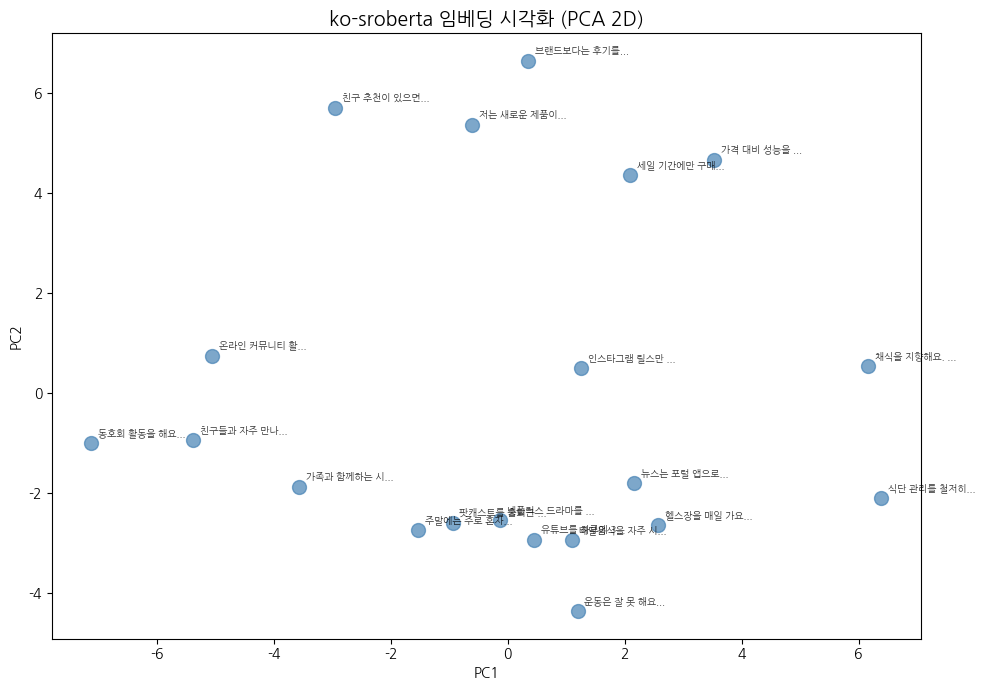

✅ 완료


In [ ]:
# 한글 폰트 설치 및 적용
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from sklearn.decomposition import PCA
import numpy as np
import os

# PCA 2D 축소
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7, s=100, c='steelblue')

for i, (x, y) in enumerate(reduced):
    plt.annotate(
        responses[i][:10]+'...',
        (x, y),
        fontproperties=font_prop,  # ← 핵심
        fontsize=7,
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('ko-sroberta 임베딩 시각화 (PCA 2D)', fontproperties=font_prop, fontsize=14)
plt.xlabel('PC1', fontproperties=font_prop)
plt.ylabel('PC2', fontproperties=font_prop)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pca_visualization.png'), dpi=150)
plt.show()
print('✅ 완료')

## K-means

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)  # 실제 데이터 오면 range(3, 15)로 변경
inertias, silhouettes = [], []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))
    print(f'k={k} | inertia={km.inertia_:.1f} | silhouette={silhouette_score(embeddings, labels):.3f}')

k=2 | inertia=1626.5 | silhouette=0.054
k=3 | inertia=1429.9 | silhouette=0.077
k=4 | inertia=1280.5 | silhouette=0.098
k=5 | inertia=1223.5 | silhouette=0.058
k=6 | inertia=1068.3 | silhouette=0.065
k=7 | inertia=1070.9 | silhouette=0.064
k=8 | inertia=960.7 | silhouette=0.014


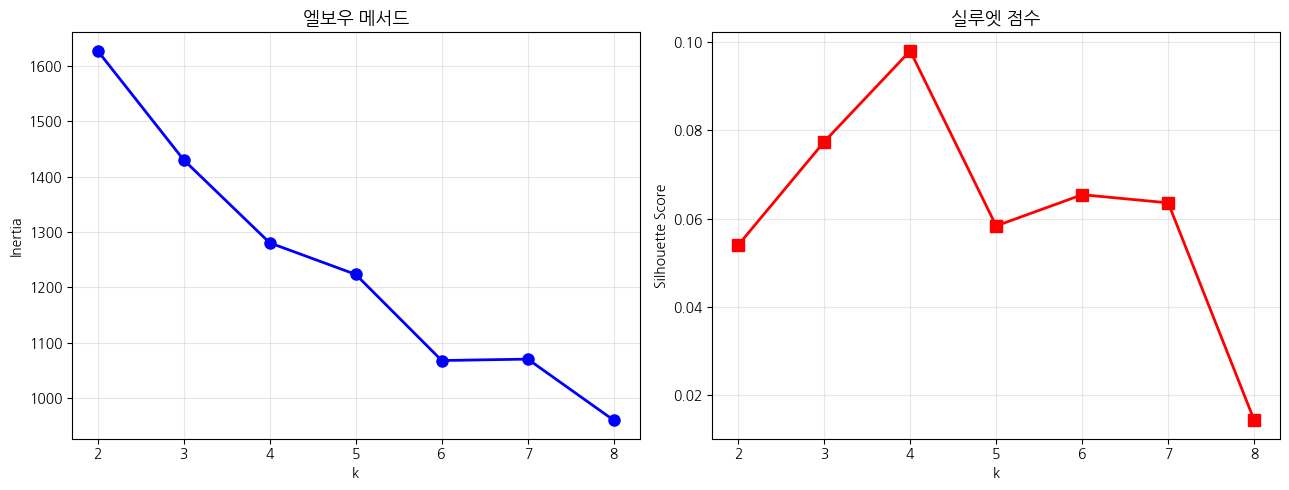

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('엘보우 메서드', fontproperties=font_prop, fontsize=13)
ax1.set_xlabel('k', fontproperties=font_prop)
ax1.set_ylabel('Inertia', fontproperties=font_prop)
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouettes, 'rs-', linewidth=2, markersize=8)
ax2.set_title('실루엣 점수', fontproperties=font_prop, fontsize=13)
ax2.set_xlabel('k', fontproperties=font_prop)
ax2.set_ylabel('Silhouette Score', fontproperties=font_prop)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'elbow_silhouette.png'), dpi=150)
plt.show()

In [ ]:
# ✏️ 그래프 보고 결정!
BEST_K = 4

km_final = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels = km_final.fit_predict(embeddings)
df['cluster'] = labels

print(f'✅ k={BEST_K}로 군집화 완료')
print(df['cluster'].value_counts().sort_index())

✅ k=4로 군집화 완료
cluster
0    5
1    2
2    9
3    4
Name: count, dtype: int64


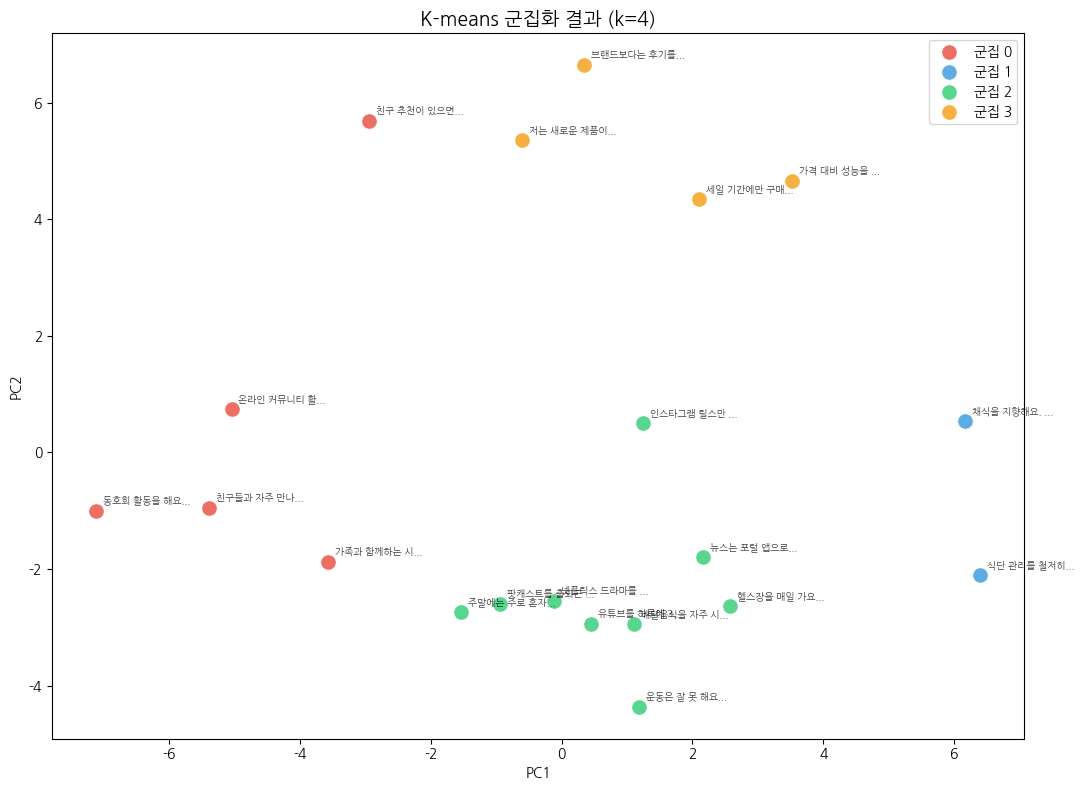

In [ ]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
pca2 = PCA(n_components=2)
reduced2 = pca2.fit_transform(embeddings)

plt.figure(figsize=(11, 8))
for cluster_id in range(BEST_K):
    mask = labels == cluster_id
    plt.scatter(reduced2[mask, 0], reduced2[mask, 1],
                c=colors[cluster_id], label=f'군집 {cluster_id}',
                alpha=0.8, s=120, edgecolors='white', linewidth=0.5)

for i, (x, y) in enumerate(reduced2):
    plt.annotate(responses[i][:10]+'...', (x, y),
                 fontproperties=font_prop, fontsize=7, alpha=0.75,
                 xytext=(5, 5), textcoords='offset points')

plt.title(f'K-means 군집화 결과 (k={BEST_K})', fontproperties=font_prop, fontsize=14)
plt.xlabel('PC1', fontproperties=font_prop)
plt.ylabel('PC2', fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'kmeans_clusters.png'), dpi=150)
plt.show()

In [ ]:
# 군집별 대표 응답 출력
for cluster_id in range(BEST_K):
    cluster_df = df[df['cluster'] == cluster_id]
    print(f'\n{"="*50}')
    print(f'  군집 {cluster_id}  ({len(cluster_df)}개 응답)')
    print(f'{"="*50}')
    for _, row in cluster_df.head(3).iterrows():
        print(f'  • {row["response"]}')

# 저장
out_path = os.path.join(SAVE_DIR, 'clustered_responses.csv')
df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n✅ 저장 완료: {out_path}')


  군집 0  (5개 응답)
  • 친구 추천이 있으면 믿고 구매해요. 입소문이 가장 중요하다고 생각해요.
  • 친구들과 자주 만나요. 주 1-2회는 꼭 모임이 있어요.
  • 가족과 함께하는 시간이 가장 중요해요. 주말은 가족과 함께해요.

  군집 1  (2개 응답)
  • 식단 관리를 철저히 해요. 탄수화물을 줄이려고 노력 중이에요.
  • 채식을 지향해요. 환경을 위해서 육류 소비를 줄이고 있어요.

  군집 2  (9개 응답)
  • 유튜브를 하루에 3시간 이상 봐요. 주로 게임 채널을 봅니다.
  • 넷플릭스 드라마를 몰아보는 걸 좋아해요. 주말에 한 시즌씩 봐요.
  • 뉴스는 포털 앱으로만 봐요. TV는 거의 안 봐요.

  군집 3  (4개 응답)
  • 저는 새로운 제품이 출시되면 바로 구매하는 편이에요. 얼리어답터라고 할 수 있죠.
  • 가격 대비 성능을 꼼꼼히 따져보고 구매합니다. 충동구매는 절대 안 해요.
  • 브랜드보다는 후기를 먼저 봐요. 리뷰가 좋으면 구매하는 편이에요.

✅ 저장 완료: /content/drive/MyDrive/graduation_project/day1_results/clustered_responses.csv


## LLM 군집 요약

In [ ]:
!pip install anthropic -q
print('✅ 설치 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 33.9 MB/s eta 0:00:00
✅ 설치 완료


In [ ]:
import requests
import json

LUXIA_API_KEY = "U2FsdGVkX1+Y36QNNuIQImw2m1DewZyECwPFPTpg6IsehGQje9j8i33QqDzgv3qBRCZVrekk2MKxAD5f1nuWWwdw0PLJ1ZvjuV30/3z+BV9uX7h/P2NrfsN+p7WPOoS8YZdmmHuNCYeVbHTQAQXRcgtDwyo6G/oRNOfAb6PsDlEFy0A8PVKt5/cpLMYXhM4A9+pccWblA5AwpU1DOZmQ9w=="

cluster_summaries = {}

for cluster_id in range(BEST_K):
    cluster_df = df[df['cluster'] == cluster_id]
    samples = cluster_df['response'].tolist()[:5]

    prompt = f"""다음은 가상 한국인 페르소나들의 응답 샘플입니다:
{chr(10).join(f'- {r}' for r in samples)}

이 그룹의 공통적인 특성과 성향을 2~3문장으로 요약해주세요.
마지막에 이 그룹을 대표하는 짧은 이름(예: "절약형 소비자")도 붙여주세요."""

    response = requests.post(
        'https://bridge.luxiacloud.com/luxia/v1/chat',
        headers={
            'apikey': LUXIA_API_KEY,
            'Content-Type': 'application/json'
        },
        json={
            'model': 'luxia3-llm-32b-0731',
            'messages': [{'role': 'user', 'content': prompt}]
        }
    )

    result = response.json()
    summary = result['choices'][0]['message']['content']
    cluster_summaries[cluster_id] = summary

    print(f'\n{"="*50}')
    print(f'  군집 {cluster_id} 요약')
    print(f'{"="*50}')
    print(summary)


  군집 0 요약
이 그룹은 가족과 친구와의 관계를 중요하게 생각하며, 입소문이나 추천을 통한 소비 결정을 선호하는 경향이 있습니다. 온라인과 오프라인 모두에서 활발한 소통을 하지만, 특히 온라인 커뮤니티를 통해 편리하게 정보를 공유하고 관계를 유지합니다.  
이 그룹을 대표하는 짧은 이름: "관계중시 입소문족"

  군집 1 요약
이 그룹은 건강과 환경을 고려하여 식습관을 친환경적으로 변경하고자 노력하는 경향이 있습니다. 그들은 식단을 철저히 관리하며, 탄수화물이나 육류 같은 특정 음식군의 소비를 줄이는 데 집중합니다.  
이 그룹을 대표하는 짧은 이름은 "건강환경형 식단가이드"입니다.

  군집 2 요약
이 그룹은 짧고 집중적인 디지털 콘텐츠 소비를 선호하며, 스트리밍 서비스와 모바일 앱을 통해 주로 정보와 오락을 얻습니다. 특히 게임, 드라마, 경제 팟캐스트 등 취향에 맞는 콘텐츠를 출퇴근이나 주말 등 시간대별로 조직적으로 이용하는 경향이 있습니다.  
이들을 "디지털 몰입형 미니멀콘"이라고 부르는 것이 적합합니다.

  군집 3 요약
이 그룹은 제품 구매 시 신중한 태도를 보이며, 가격이나 후기, 혹은 할인 여부를 중요한 기준으로 삼습니다. 자신만의 구매 원칙에 따라 충동구매를 지양하고, 정보 수집을 통해 신중하게 선택하는 성향이 있습니다.

공통 이름: "리서치형 소비자"


In [ ]:
import json

# JSON으로 저장
summary_path = os.path.join(SAVE_DIR, 'cluster_summaries.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(cluster_summaries, f, ensure_ascii=False, indent=2)

# CSV에도 요약 컬럼 추가
df['cluster_summary'] = df['cluster'].map(cluster_summaries)
final_path = os.path.join(SAVE_DIR, 'final_results.csv')
df.to_csv(final_path, index=False, encoding='utf-8-sig')

print(f'✅ 요약 저장: {summary_path}')
print(f'✅ 최종 결과 저장: {final_path}')

✅ 요약 저장: /content/drive/MyDrive/graduation_project/day1_results/cluster_summaries.json
✅ 최종 결과 저장: /content/drive/MyDrive/graduation_project/day1_results/final_results.csv
